# Получение оригинальной матрицы изображения

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r"picture1.png"  #никакой кириллицы тут в пути!!!
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError('Изображение не грузанулось')

img = cv2.resize(img, (256, 256))
imgf = img.astype(np.float64)
print(imgf)

[[ 58.  61.  61. ... 124. 124. 124.]
 [ 58.  60.  61. ... 124. 125. 124.]
 [ 60.  60.  61. ... 125. 125. 124.]
 ...
 [ 97.  96.  94. ...  68.  71.  87.]
 [170. 170. 169. ...  68.  72.  85.]
 [216. 217. 216. ...  67.  72.  75.]]


## Пример

In [ ]:
# >>>>-------------Пример------------>
image = [
    [4, 6, 10, 12],
    [4, 6, 10, 12],
    [8, 10, 14, 16],
    [8, 10, 14, 16]
]
image = np.array(image)


# Вывод картинки

Оригинальное изображение


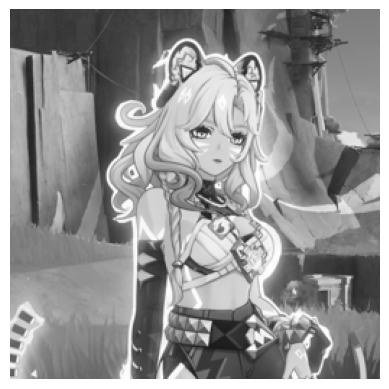

In [4]:
def show_matrix_as_image(matrix):
    plt.imshow(matrix, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')
    plt.show()
print("Оригинальное изображение")
show_matrix_as_image(img)

# Преобразование Хаара

Преобразование Хаара (Haar Wavelet Transform)

Пусть у нас есть сигнал  
$C^0 = \{ c_0^0, c_1^0, c_2^0, \dots, c_{N-1}^0 \}$, где $N$ — чётное.

Разделим сигнал на чётные и нечётные элементы:

- Чётные: $c_{2k}^0$
- Нечётные: $c_{2k+1}^0$

---

Прямое преобразование (де-композиция)

**Приближённые коэффициенты (low-pass):**

$$
c_k^1 = \frac{c_{2k}^0 + c_{2k+1}^0}{\sqrt{2}}, \quad k = 0, 1, \dots, \frac{N}{2} - 1
$$

**Детализирующие коэффициенты (high-pass):**

$$
d_k^1 = \frac{c_{2k}^0 - c_{2k+1}^0}{\sqrt{2}}, \quad k = 0, 1, \dots, \frac{N}{2} - 1
$$

---

Обратное преобразование (ре-конструкция)

По приближённым и детализирующим коэффициентам $c_k^1$ и $d_k^1$ восстанавливаем исходный сигнал:

$$
c_{2k}^0 = \frac{c_k^1 + d_k^1}{\sqrt{2}}, \quad k = 0, 1, \dots, \frac{N}{2} - 1
$$

$$
c_{2k+1}^0 = \frac{c_k^1 - d_k^1}{\sqrt{2}}, \quad k = 0, 1, \dots, \frac{N}{2} - 1
$$


In [7]:
def haar(mat):
    shir = len(mat[0])     #ширина матрицы
    vi = len(mat)       #высота матрицы
    local_res = list()
    low_res = list()
    hi_res = list()
    res = list()
    for i in range(vi): #обходим строки
        for j in range(0, shir, 2):
            low = (mat[i][j] + mat[i][j + 1]) / np.sqrt(2)
            hi = (mat[i][j] - mat[i][j + 1]) / np.sqrt(2)
            low_res.append(low)
            hi_res.append(hi)
            #print(low_res, hi_res)
        local_res.append(low_res + hi_res)
        #print(local_res)
        #print("")
        low_res.clear()
        hi_res.clear()
    #print(local_res)
    for j in range(shir): #обходим столбцы
        for i in range(0, vi, 2):
            low = (local_res[i][j] + local_res[i + 1][j]) / np.sqrt(2)
            hi = (local_res[i][j] - local_res[i + 1][j]) / np.sqrt(2)
            low_res.append(low)
            hi_res.append(hi)
        res.append(low_res + hi_res)
        low_res.clear()
        hi_res.clear()
    res_matrix = np.array(res)
    return res_matrix.T


In [ ]:
imhar = haar(image)
print(imhar)

[[10. 22. -2. -2.]
 [18. 30. -2. -2.]
 [ 0.  0.  0.  0.]
 [ 0.  0.  0.  0.]]


# Восстановление матрицы изображения

In [ ]:
def inverse_haar(LL, LH, HL, HH):
    h, w = LL.shape
    result = np.zeros((h * 2, w * 2), dtype=float)

    for i in range(h):
        for j in range(w):
            a = LL[i, j]
            b = LH[i, j]
            c = HL[i, j]
            d = HH[i, j]

            # Восстановление четырёх пикселей из коэффициентов
            result[2*i,   2*j]   = (a + b + c + d) / 2
            result[2*i,   2*j+1] = (a - b + c - d) / 2
            result[2*i+1, 2*j]   = (a + b - c - d) / 2
            result[2*i+1, 2*j+1] = (a - b - c + d) / 2

    return result


## Пример

In [ ]:
# >>>>-------------Пример------------>
print(quant(imhar, 2))

[[ 4. 12.  0.  0.]
 [ 8. 16.  0.  0.]
 [ 0.  0.  0.  0.]
 [ 0.  0.  0.  0.]]


In [146]:
# >>>>-------------Пример------------>
image = [
    [4, 6, 10, 12],
    [4, 6, 10, 12],
    [8, 10, 14, 16],
    [8, 10, 14, 16]
]
image = np.array(image)
imhar = haar(image)
print(imhar)
LL = imhar[:2, :2]
print(LL)
#LH = np.zeros_like(LL)
LH = np.array([[-1, -1], [-1, -1]])
print(inverse_haar(LL, LH, np.zeros_like(LL), np.zeros_like(LL)))

[[10. 22. -2. -2.]
 [18. 30. -2. -2.]
 [ 0.  0.  0.  0.]
 [ 0.  0.  0.  0.]]
[[10. 22.]
 [18. 30.]]
[[ 4.5  5.5 10.5 11.5]
 [ 4.5  5.5 10.5 11.5]
 [ 8.5  9.5 14.5 15.5]
 [ 8.5  9.5 14.5 15.5]]


# Квантование

In [45]:
def quant(mat, d):
    shir = len(mat[0])     #ширина матрицы
    vi = len(mat)       #высота матрицы
    
    for i in range(vi):
        for j in range(shir):
            mat[i][j] = round(mat[i][j] / d) * d
    return mat

# «Cобранные» программы

## Квантование + сохранение только LL на первых трёх шагах

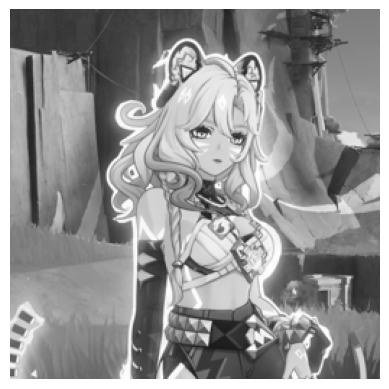

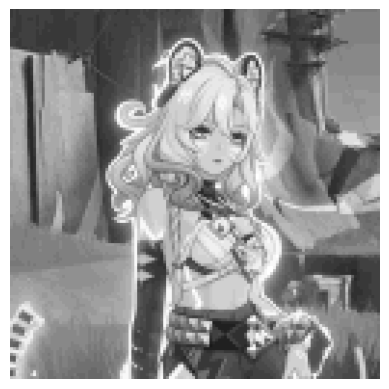

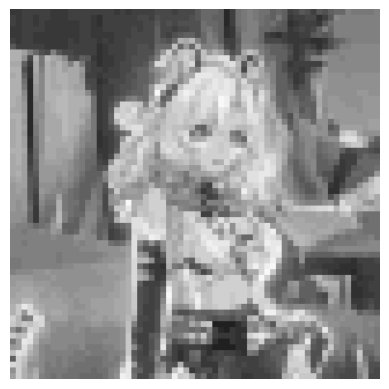

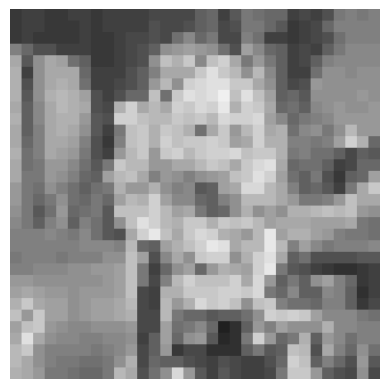

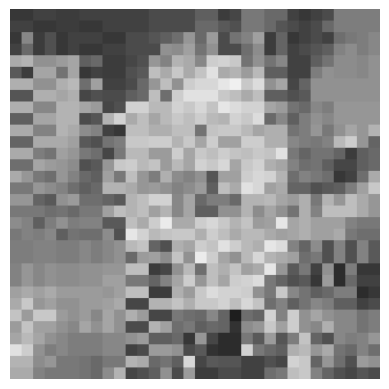

Средняя дисперсия:  1631.2005004882812


In [ ]:
def show_matrix_as_image(matrix):
    plt.imshow(matrix, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')
    plt.show()
show_matrix_as_image(img)

loc_res = haar(imgf)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL1 = quant(loc_res[:new_shir, :new_vi], 16)

inv1 = inverse_haar(LL1, np.zeros_like(LL1), np.zeros_like(LL1), np.zeros_like(LL1))
show_matrix_as_image(inv1)


loc_res = haar(LL1)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL2 = quant(loc_res[:new_shir, :new_vi], 32)

inv2 = inverse_haar(LL2, np.zeros_like(LL2), np.zeros_like(LL2), np.zeros_like(LL2))
inv1 = inverse_haar(inv2, np.zeros_like(inv2), np.zeros_like(inv2), np.zeros_like(inv2))
show_matrix_as_image(inv1)


loc_res = haar(LL2)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL3 = quant(loc_res[:new_shir, :new_vi], 64)

inv3 = inverse_haar(LL3, np.zeros_like(LL3), np.zeros_like(LL3), np.zeros_like(LL3))
inv2 = inverse_haar(inv3, np.zeros_like(inv3), np.zeros_like(inv3), np.zeros_like(inv3))
inv1 = inverse_haar(inv2, np.zeros_like(inv2), np.zeros_like(inv2), np.zeros_like(inv2))
show_matrix_as_image(inv1)


loc_res = haar(LL3)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL4 = quant(loc_res[:new_shir, :new_vi], 80)
LH4 = quant(loc_res[new_shir:, :new_vi], 80)
HL4 = quant(loc_res[:new_shir, new_vi:], 80)
HH4 = quant(loc_res[new_shir:, new_vi:], 80)   


LL3 = inverse_haar(LL4, LH4, HL4, HH4)
LL2 = inverse_haar(LL3, np.zeros_like(LL3), np.zeros_like(LL3), np.zeros_like(LL3))
LL1 = inverse_haar(LL2, np.zeros_like(LL2), np.zeros_like(LL2), np.zeros_like(LL2))
LL = inverse_haar(LL1, np.zeros_like(LL1), np.zeros_like(LL1), np.zeros_like(LL1))

show_matrix_as_image(LL)

disp = 0
for i in range(0, 256):
    for j in range(0, 256):
        disp = disp + ((imgf[i][j] - LL[i][j]) / 256) ** 2
print("Средняя дисперсия: ", disp)

## Без квантования + сохранение только LL на первых трёх шагах

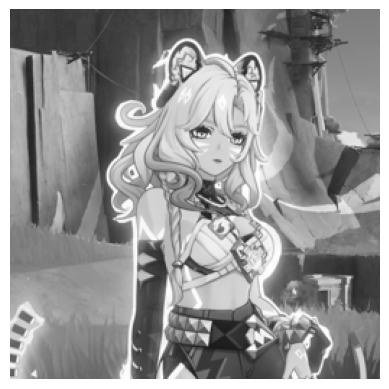

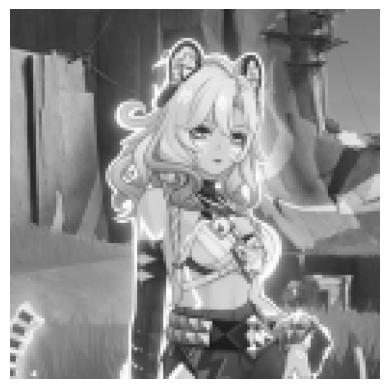

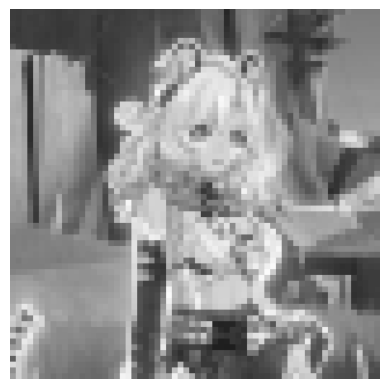

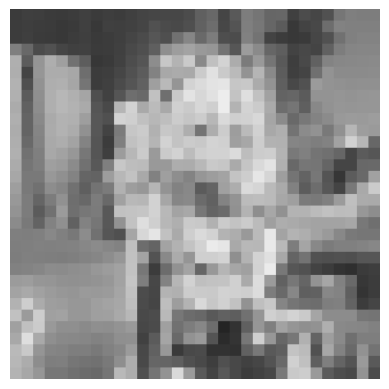

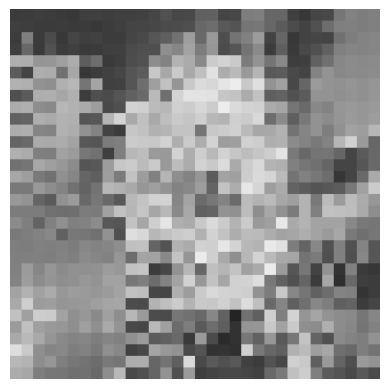

Средняя дисперсия:  1619.869818687439


In [ ]:
def show_matrix_as_image(matrix):
    plt.imshow(matrix, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')
    plt.show()
show_matrix_as_image(img)

loc_res = haar(imgf)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL1 = loc_res[:new_shir, :new_vi]

inv1 = inverse_haar(LL1, np.zeros_like(LL1), np.zeros_like(LL1), np.zeros_like(LL1))
show_matrix_as_image(inv1)


loc_res = haar(LL1)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL2 = loc_res[:new_shir, :new_vi]

inv2 = inverse_haar(LL2, np.zeros_like(LL2), np.zeros_like(LL2), np.zeros_like(LL2))
inv1 = inverse_haar(inv2, np.zeros_like(inv2), np.zeros_like(inv2), np.zeros_like(inv2))
show_matrix_as_image(inv1)


loc_res = haar(LL2)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL3 = loc_res[:new_shir, :new_vi]

inv3 = inverse_haar(LL3, np.zeros_like(LL3), np.zeros_like(LL3), np.zeros_like(LL3))
inv2 = inverse_haar(inv3, np.zeros_like(inv3), np.zeros_like(inv3), np.zeros_like(inv3))
inv1 = inverse_haar(inv2, np.zeros_like(inv2), np.zeros_like(inv2), np.zeros_like(inv2))
show_matrix_as_image(inv1)


loc_res = haar(LL3)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL4 = loc_res[:new_shir, :new_vi]
LH4 = loc_res[new_shir:, :new_vi]
HL4 = loc_res[:new_shir, new_vi:]
HH4 = loc_res[new_shir:, new_vi:]   

LL3 = inverse_haar(LL4, LH4, HL4, HH4)
LL2 = inverse_haar(LL3, np.zeros_like(LL3), np.zeros_like(LL3), np.zeros_like(LL3))
LL1 = inverse_haar(LL2, np.zeros_like(LL2), np.zeros_like(LL2), np.zeros_like(LL2))
LL = inverse_haar(LL1, np.zeros_like(LL1), np.zeros_like(LL1), np.zeros_like(LL1))

show_matrix_as_image(LL)

disp = 0
for i in range(0, 256):
    for j in range(0, 256):
        disp = disp + ((imgf[i][j] - LL[i][j]) / 256) ** 2
print("Средняя дисперсия: ", disp)

## Без квантования + сохранение всех доп компонент

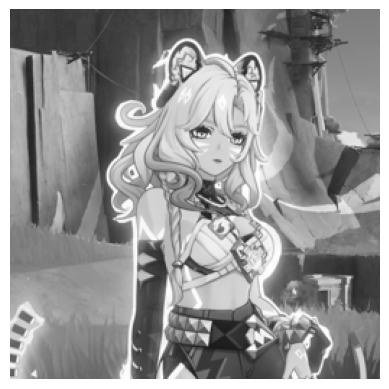

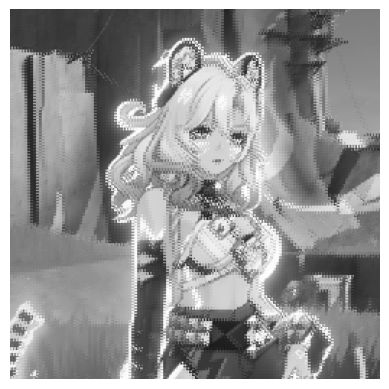

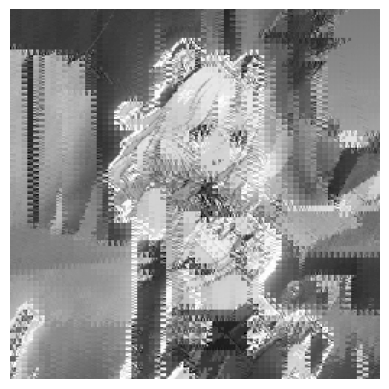

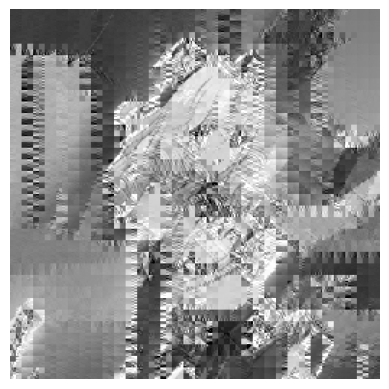

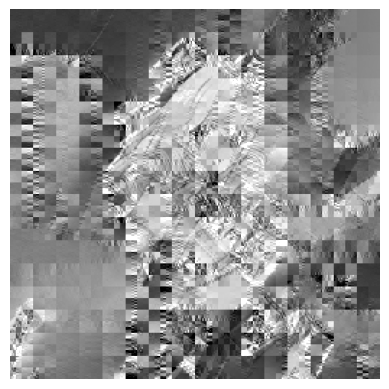

Средняя дисперсия:  2253.9246191978455


In [154]:
def show_matrix_as_image(matrix):
    plt.imshow(matrix, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')
    plt.show()
show_matrix_as_image(img)

loc_res = haar(imgf)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL1 = loc_res[:new_shir, :new_vi]
LH1 = loc_res[new_shir:, :new_vi]
HL1 = loc_res[:new_shir, new_vi:]
HH1 = loc_res[new_shir:, new_vi:]

inv1 = inverse_haar(LL1, LH1, HL1, HH1)
show_matrix_as_image(inv1)


loc_res = haar(LL1)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL2 = loc_res[:new_shir, :new_vi]
LH2 = loc_res[new_shir:, :new_vi]
HL2 = loc_res[:new_shir, new_vi:]
HH2 = loc_res[new_shir:, new_vi:]

inv2 = inverse_haar(LL2, LH2, HL2, HH2)
inv1 = inverse_haar(inv2, LH1, HL1, HH1)
show_matrix_as_image(inv1)


loc_res = haar(LL2)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL3 = loc_res[:new_shir, :new_vi]
LH3 = loc_res[new_shir:, :new_vi]
HL3 = loc_res[:new_shir, new_vi:]
HH3 = loc_res[new_shir:, new_vi:]

inv3 = inverse_haar(LL3, LH3, HL3, HH3)
inv2 = inverse_haar(inv3, LH2, HL2, HH2)
inv1 = inverse_haar(inv2, LH1, HL1, HH1)
show_matrix_as_image(inv1)


loc_res = haar(LL3)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL4 = loc_res[:new_shir, :new_vi]
LH4 = loc_res[new_shir:, :new_vi]
HL4 = loc_res[:new_shir, new_vi:]
HH4 = loc_res[new_shir:, new_vi:]

LL3 = inverse_haar(LL4, LH4, HL4, HH4)
LL2 = inverse_haar(LL3, LH3, HL3, HH3)
LL1 = inverse_haar(LL2, LH2, HL2, HH2)
LL = inverse_haar(LL1, LH1, HL1, HH1)

show_matrix_as_image(LL)

disp = 0
for i in range(0, 256):
    for j in range(0, 256):
        disp = disp + ((imgf[i][j] - LL[i][j]) / 256) ** 2
print("Средняя дисперсия: ", disp)